Probabilidad Laura Fernández gana en 1ra Ronda: 64.10%
Media proyectada LF: 45.25%


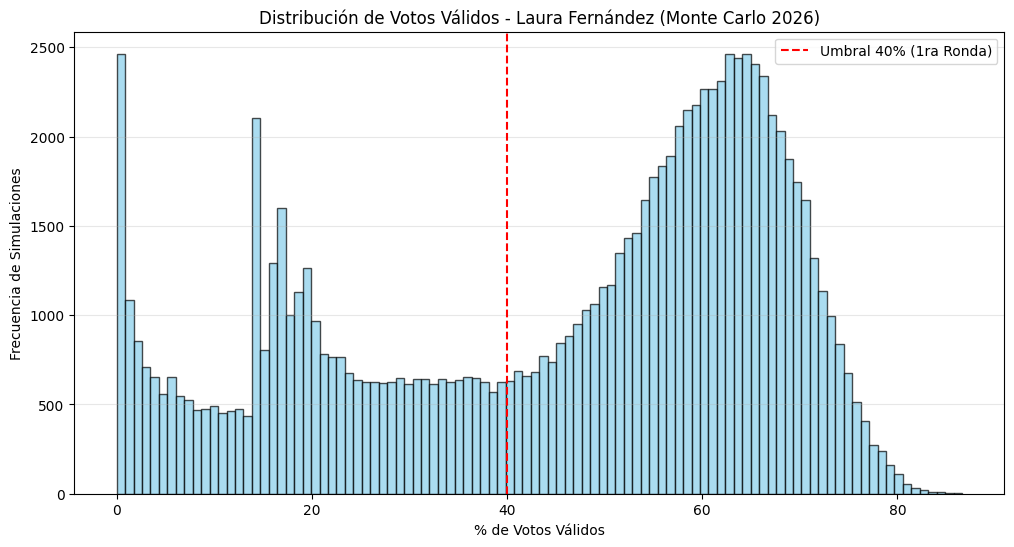

Resultados guardados en: simulaciones_mc_2026.csv


In [2]:
# 1. INSTALACIÓN Y PREPARACIÓN (Solo por si acaso, aunque Colab ya las trae)
!pip install -q numpy pandas matplotlib

import math
import json
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Esto permite que los gráficos se muestren dentro de las celdas de Colab
%matplotlib inline

# =========================
# Configuración principal
# =========================
ELECTION_DATE = pd.Timestamp("2026-02-01")
SEED = 20260121
N_SIMS = 100_000  # En Colab 100k-200k corre rápido (aprox 1 min)

EXPORT_SIMULATIONS = True
SIM_CSV_PATH = "simulaciones_mc_2026.csv"
SUMMARY_JSON_PATH = "resumen_mc_2026.json"
FIG_PATH = "figura_mc_2026.png"

CANDIDATES = [
    "LAURA FERNÁNDEZ",
    "ÁLVARO RAMOS",
    "CLAUDIA DOBLES",
    "ARIEL ROBLES",
    "FABRICIO ALVARADO",
    "JOSÉ AGUILAR",
    "OTROS",
]

INDECISION_MIX = {
    "proporcional": 0.35,
    "momentum": 0.30,
    "dispersion": 0.20,
    "abstencion": 0.15,
}

MOMENTUM_FACTOR_MEAN = 1.50
MOMENTUM_FACTOR_SD = 0.15
ABSTENTION_FRAC_MEAN = 0.70
ABSTENTION_FRAC_SD = 0.10
DISPERSION_TO_RESTO_MEAN = 0.35
DISPERSION_TO_RESTO_SD = 0.10
NULL_BLANK_MEAN = 0.02
NULL_BLANK_SD = 0.01
NULL_BLANK_MAX = 0.08

# =========================
# Estructura de Datos
# =========================
@dataclass
class Poll:
    poll_id: str
    pollster: str
    publish_date: str
    question_type: str
    moe: float
    values: Dict[str, Optional[float]]

    def to_row(self) -> Dict:
        row = {"poll_id": self.poll_id, "pollster": self.pollster, "publish_date": self.publish_date, "question_type": self.question_type, "moe": self.moe}
        row.update(self.values)
        return row

# Pool de encuestas actualizado al 21-ene-2026
POLLS: List[Poll] = [
    Poll("ciep_ucr_1", "CIEP-UCR", "2025-10-22", "abierta", 2.7, {"INDECISOS": 55.0, "LAURA FERNÁNDEZ": 25.0, "ÁLVARO RAMOS": 7.0, "ARIEL ROBLES": 3.0, "CLAUDIA DOBLES": 3.0, "OTROS": 4.1, "NULO/BLANCO": 2.5}),
    Poll("idespo_una_1", "IDESPO-UNA", "2025-11-06", "abierta", 3.3, {"INDECISOS": 52.4, "LAURA FERNÁNDEZ": 28.1, "ÁLVARO RAMOS": 6.2, "ARIEL ROBLES": 2.3, "CLAUDIA DOBLES": 2.9, "OTROS": 3.3, "NO RESPONDE": 1.6, "NULO/BLANCO": 2.0}),
    Poll("opol_1", "OPOL", "2025-10-29", "papeleta", 2.2, {"INDECISOS": 38.79, "LAURA FERNÁNDEZ": 31.2, "ÁLVARO RAMOS": 7.41, "FABRICIO ALVARADO": 4.84, "ARIEL ROBLES": 3.72, "CLAUDIA DOBLES": 2.92, "OTROS": 2.24, "NO RESPONDE": 0.24, "NULO/BLANCO": 1.8}),
    Poll("demoscopia_1", "Demoscopia", "2025-11-13", "abierta", 2.83, {"INDECISOS": 56.7, "LAURA FERNÁNDEZ": 21.4, "ÁLVARO RAMOS": 9.0, "FABRICIO ALVARADO": 3.7, "ARIEL ROBLES": 2.1, "CLAUDIA DOBLES": 3.0, "OTROS": 4.1}),
    Poll("opol_2", "OPOL", "2025-11-12", "papeleta", 2.16, {"INDECISOS": 42.3, "LAURA FERNÁNDEZ": 21.0, "ÁLVARO RAMOS": 10.4, "FABRICIO ALVARADO": 6.5, "ARIEL ROBLES": 4.1, "CLAUDIA DOBLES": 2.9, "OTROS": 2.7}),
    Poll("opol_3", "OPOL", "2025-11-25", "papeleta", 2.10, {"INDECISOS": 37.37, "LAURA FERNÁNDEZ": 37.85, "ÁLVARO RAMOS": 7.19, "FABRICIO ALVARADO": 3.97, "ARIEL ROBLES": 2.35, "CLAUDIA DOBLES": 1.29, "OTROS": 2.11, "NO RESPONDE": 0.5, "NULO/BLANCO": 1.03}),
    Poll("ciep_ucr_2", "CIEP-UCR", "2025-12-03", "papeleta", 2.3, {"INDECISOS": 45.0, "LAURA FERNÁNDEZ": 30.0, "ÁLVARO RAMOS": 8.0, "FABRICIO ALVARADO": 1.0, "ARIEL ROBLES": 5.0, "CLAUDIA DOBLES": 4.0, "OTROS": 1.5, "NULO/BLANCO": 2.6}),
    Poll("idespo_una_2", "IDESPO-UNA", "2025-12-08", "panel", 3.3, {"INDECISOS": 43.9, "LAURA FERNÁNDEZ": 32.8, "ÁLVARO RAMOS": 6.6, "ARIEL ROBLES": 3.7, "CLAUDIA DOBLES": 5.2, "OTROS": 4.4, "NO RESPONDE": 1.6, "NULO/BLANCO": 1.8}),
    Poll("opol_4", "OPOL", "2025-12-10", "abierta", 2.24, {"INDECISOS": 32.67, "LAURA FERNÁNDEZ": 38.01, "ÁLVARO RAMOS": 6.12, "FABRICIO ALVARADO": 3.81, "ARIEL ROBLES": 3.63, "CLAUDIA DOBLES": 2.39, "OTROS": 3.91, "NULO/BLANCO": 2.15}),
    Poll("demoscopia_2", "Demoscopia", "2025-12-16", "papeleta", 2.83, {"INDECISOS": 41.7, "LAURA FERNÁNDEZ": 27.4, "ÁLVARO RAMOS": 11.3, "FABRICIO ALVARADO": 3.6, "ARIEL ROBLES": 4.8, "CLAUDIA DOBLES": 3.1, "OTROS": 3.1, "NO RESPONDE": 2.15, "NULO/BLANCO": 2.91}),
    Poll("opol_5", "OPOL", "2025-12-23", "papeleta", 2.11, {"INDECISOS": 33.77, "LAURA FERNÁNDEZ": 39.45, "ÁLVARO RAMOS": 5.64, "FABRICIO ALVARADO": 2.98, "ARIEL ROBLES": 3.13, "CLAUDIA DOBLES": 2.63, "OTROS": 2.64, "NULO/BLANCO": 2.91}),
    Poll("cid_gallup", "CID Gallup", "2026-01-06", "lista", 2.87, {"INDECISOS": 14.0, "LAURA FERNÁNDEZ": 41.0, "ÁLVARO RAMOS": 9.0, "FABRICIO ALVARADO": 6.0, "ARIEL ROBLES": 4.0, "CLAUDIA DOBLES": 4.0, "JOSÉ AGUILAR": 2.0, "OTROS": 4.0, "NO RESPONDE": 11.0}),
    Poll("ciep_ucr_3", "CIEP-UCR", "2026-01-21", "papeleta", 3.1, {"INDECISOS": 32.0, "LAURA FERNÁNDEZ": 40.0, "ÁLVARO RAMOS": 8.0, "CLAUDIA DOBLES": 5.0, "ARIEL ROBLES": 4.0, "FABRICIO ALVARADO": 4.0, "JOSÉ AGUILAR": 4.0, "OTROS": 3.0}),
]

# =========================
# Lógica de Simulación
# =========================
def polls_to_frame(polls: List[Poll]) -> pd.DataFrame:
    df = pd.DataFrame([p.to_row() for p in polls])
    df["publish_date"] = pd.to_datetime(df["publish_date"])
    df["n_eff"] = 0.25 * (1.96 * 100.0 / df["moe"]) ** 2
    for c in ["INDECISOS", "NO RESPONDE", "NULO/BLANCO"] + CANDIDATES:
        if c not in df.columns: df[c] = np.nan
    df["NO RESPONDE"] = df["NO RESPONDE"].fillna(0.0)
    nb_med = df.loc[df["question_type"].isin(["papeleta", "lista"]), "NULO/BLANCO"].median()
    df["NULO/BLANCO"] = df["NULO/BLANCO"].fillna(nb_med if not np.isnan(nb_med) else 2.0)
    df["U"] = (df["INDECISOS"].fillna(0.0) + df["NO RESPONDE"].fillna(0.0)).clip(0, 95)
    df["B"] = df["NULO/BLANCO"].clip(0, 20)
    df["DECIDED_TOTAL"] = (100.0 - df["U"] - df["B"]).clip(1e-6)
    for c in CANDIDATES: df[c] = df[c].fillna(0.0)
    df["RESTO_TOTAL"] = (df["DECIDED_TOTAL"] - df[CANDIDATES].sum(axis=1)).clip(0)
    for c in CANDIDATES: df[f"S_{c}"] = (df[c] / df["DECIDED_TOTAL"]).clip(0)
    df["S_RESTO"] = (df["RESTO_TOTAL"] / df["DECIDED_TOTAL"]).clip(0)
    share_cols = [f"S_{c}" for c in CANDIDATES] + ["S_RESTO"]
    df[share_cols] = df[share_cols].div(df[share_cols].sum(axis=1).replace(0, 1.0), axis=0)
    return df.sort_values("publish_date").reset_index(drop=True)

def compute_weights(df: pd.DataFrame, half_life_days: float = 21.0) -> pd.Series:
    days_to_election = (ELECTION_DATE - df["publish_date"]).dt.days.clip(lower=0)
    decay = np.exp(-math.log(2.0) * (days_to_election / half_life_days))
    q = df["question_type"].str.lower()
    factor = np.where(q == "papeleta", 1.0, np.where(q == "lista", 1.0, np.where(q == "abierta", 0.75, 0.8)))
    return df["n_eff"] * decay * factor

def fit_undecided_beta(df: pd.DataFrame, w: np.ndarray) -> Tuple[float, float]:
    u = (df["U"].values / 100.0).clip(1e-4, 1-1e-4)
    mu = np.sum(w * u) / np.sum(w)
    v = max(np.sum(w * (u - mu) ** 2) / np.sum(w), 1e-5)
    k = (mu * (1 - mu) / v) - 1
    return mu * max(k, 2.0), (1 - mu) * max(k, 2.0)

def fit_shares_logit_normal(df: pd.DataFrame, w: np.ndarray) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    share_cols = [f"S_{c}" for c in CANDIDATES] + ["S_RESTO"]
    S = df[share_cols].values
    base = np.clip(S[:, -1], 1e-6, 1.0)
    Y = np.log(np.clip(S[:, :-1], 1e-6, 1.0) / base[:, None])
    w_norm = w / np.sum(w)
    mu = np.sum(Y * w_norm[:, None], axis=0)
    Z = Y - mu
    cov = (Z.T @ (Z * w_norm[:, None])) + np.eye(Y.shape[1]) * 0.02
    return mu, cov, CANDIDATES

def simulate(df: pd.DataFrame, n_sims: int, seed: int) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    w = compute_weights(df).values
    aU, bU = fit_undecided_beta(df, w)
    mu_y, cov_y, cand_names = fit_shares_logit_normal(df, w)
    scen_names = list(INDECISION_MIX.keys())
    scen_probs = np.array(list(INDECISION_MIX.values())); scen_probs /= scen_probs.sum()

    results = []
    # Simulación vectorizada parcial para velocidad
    for _ in range(n_sims):
        U = rng.beta(aU, bU)
        B = rng.beta(2, 50) * NULL_BLANK_MAX # Simplificado para Colab
        y = rng.multivariate_normal(mu_y, cov_y)
        expy = np.exp(np.clip(y, -12, 12))
        s_base = 1.0 / (1.0 + expy.sum())
        s = expy * s_base

        scen = rng.choice(scen_names, p=scen_probs)
        abst = rng.normal(ABSTENTION_FRAC_MEAN, ABSTENTION_FRAC_SD) if scen == "abstencion" else 0.0
        U_vota = U * (1.0 - np.clip(abst, 0, 1))

        # Reparto (Proporcional por defecto)
        alloc = s * U_vota / (s.sum() + s_base)
        resto_alloc = s_base * U_vota / (s.sum() + s_base)

        # Ajuste Momentum
        if scen == "momentum":
            idx_leader = np.argmax(s)
            factor = np.clip(rng.normal(MOMENTUM_FACTOR_MEAN, MOMENTUM_FACTOR_SD), 1.1, 2.5)
            s_adj = s.copy(); s_adj[idx_leader] *= factor
            alloc = s_adj * U_vota / (s_adj.sum() + s_base)
            resto_alloc = s_base * U_vota / (s_adj.sum() + s_base)

        votes = (1.0 - U - B) * s + alloc
        resto_votes = (1.0 - U - B) * s_base + resto_alloc
        valid_sum = votes.sum() + resto_votes

        row = {cand: 100.0 * v / valid_sum for cand, v in zip(cand_names, votes)}
        row["RESTO"] = 100.0 * resto_votes / valid_sum
        row["scenario"] = scen
        results.append(row)

    sim_df = pd.DataFrame(results)
    sim_df["LF_wins_R1"] = sim_df["LAURA FERNÁNDEZ"] >= 40.0
    return sim_df

# =========================
# Ejecución y Visualización
# =========================
df_encuestas = polls_to_frame(POLLS)
sim_df = simulate(df_encuestas, N_SIMS, SEED)

# Reporte en pantalla
print(f"Probabilidad Laura Fernández gana en 1ra Ronda: {sim_df['LF_wins_R1'].mean():.2%}")
print(f"Media proyectada LF: {sim_df['LAURA FERNÁNDEZ'].mean():.2f}%")

# Gráfico
plt.figure(figsize=(12, 6))
plt.hist(sim_df["LAURA FERNÁNDEZ"], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(40, color='red', linestyle='--', label='Umbral 40% (1ra Ronda)')
plt.title("Distribución de Votos Válidos - Laura Fernández (Monte Carlo 2026)")
plt.xlabel("% de Votos Válidos")
plt.ylabel("Frecuencia de Simulaciones")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Guardar resultados en archivos de Colab
sim_df.to_csv(SIM_CSV_PATH, index=False)
print(f"Resultados guardados en: {SIM_CSV_PATH}")